# LGBM 모델링 과정



In [6]:
# 데이터 로드-> train,test 스플릿-> EDA-> 결측치 제거->이상치 조정->피처 생성->인코딩/스케일링->모델링->CV->모델평가->모델 저장

# 데이터 로드 및 확인

In [7]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.seed import set_seed
from src.pipeline.missing_value import CJ_MissingValue, JH_MissingValue, JH_train_stats
from src.pipeline.outlier_control import OutlierControl

In [8]:
dataset = pd.read_excel('C:\Dev\project\SKN27-2nd-4TEAM\data\dataset.xlsx')

In [9]:
dataset.shape

(5630, 20)

In [10]:
dataset.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [11]:
dataset.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 데이터 타입 변경

In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [13]:
df_object = dataset.select_dtypes(include='object')
df_object.columns
df_int = dataset.select_dtypes(include='int64')
df_int.columns
df_float = dataset.select_dtypes(include='float64')
df_float.columns

for col in df_object.columns:
  dataset[col]=dataset[col].astype('category')

for col in df_int.columns:
  dataset[col]=dataset[col].astype('int32')

for col in df_float.columns:
  dataset[col]=dataset[col].astype('float32')

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   CustomerID                   5630 non-null   int32   
 1   Churn                        5630 non-null   int32   
 2   Tenure                       5366 non-null   float32 
 3   PreferredLoginDevice         5630 non-null   category
 4   CityTier                     5630 non-null   int32   
 5   WarehouseToHome              5379 non-null   float32 
 6   PreferredPaymentMode         5630 non-null   category
 7   Gender                       5630 non-null   category
 8   HourSpendOnApp               5375 non-null   float32 
 9   NumberOfDeviceRegistered     5630 non-null   int32   
 10  PreferedOrderCat             5630 non-null   category
 11  SatisfactionScore            5630 non-null   int32   
 12  MaritalStatus                5630 non-null   category
 13  Num

# train/test 스플릿

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
set_seed()
y = dataset['Churn'] # target data
X = dataset.drop(['Churn'], axis=1) #feature data

In [17]:
set_seed()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=dataset['Churn'])

In [18]:
X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((3941, 19), (1689, 19), (3941,), (1689,))

In [19]:
X_tr.shape[0] == y_tr.shape[0] , X_te.shape[0] == y_te.shape[0]

(True, True)

In [20]:
X_tr.shape[1] == X_te.shape[1]

True

In [21]:
X_tr['CustomerID'].nunique(), X_tr.shape[0]

(3941, 3941)

In [22]:
set_seed()
X_tr.drop('CustomerID',axis=1,inplace=True)

In [23]:
X_tr.head()

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1186,NaN,Computer,1,20.0,Credit Card,Female,2.0,3,Mobile Phone,3,Single,2,0,16.0,1.0,1.0,0.0,115.139999
3145,7.0,Mobile Phone,1,7.0,Credit Card,Female,4.0,3,Grocery,3,Married,6,0,20.0,NaN,2.0,6.0,286.839996
608,0.0,Mobile Phone,1,8.0,Credit Card,Male,2.0,1,Laptop & Accessory,2,Divorced,2,0,12.0,1.0,1.0,3.0,154.720001
5202,18.0,Computer,1,12.0,Debit Card,Male,3.0,5,Mobile Phone,3,Single,5,0,15.0,1.0,2.0,4.0,156.619995
4133,16.0,Mobile Phone,1,9.0,Debit Card,Male,3.0,4,Others,3,Married,7,0,NaN,2.0,5.0,15.0,313.799988


In [24]:
set_seed()
X_te.set_index(['CustomerID'], inplace=True)
print(f'{X_te.shape}')
X_te.head()

(1689, 18)


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
CustomerID,,,,,,,,,,,,,,,,,,
50175,24.0,Mobile Phone,1,8.0,Credit Card,Male,2.0,5,Laptop & Accessory,4,Married,6,0,18.0,0.0,1.0,2.0,154.820007
55499,1.0,Phone,3,16.0,Credit Card,Male,3.0,4,Mobile Phone,1,Single,3,0,14.0,1.0,2.0,1.0,135.809998
54706,4.0,Mobile Phone,3,34.0,E wallet,Male,4.0,4,Laptop & Accessory,1,Married,9,0,24.0,3.0,8.0,8.0,178.039993
51155,7.0,Computer,1,NaN,CC,Male,2.0,3,Mobile,4,Married,2,1,12.0,1.0,2.0,3.0,123.419998
54851,5.0,Mobile Phone,1,19.0,Credit Card,Female,3.0,4,Laptop & Accessory,1,Married,2,1,12.0,7.0,9.0,6.0,183.550003


# 결측치 처리

In [25]:
print(X_tr.isnull().sum())

Tenure                         182
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                186
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 173
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    178
CouponUsed                     183
OrderCount                     186
DaySinceLastOrder              214
CashbackAmount                   0
dtype: int64


In [26]:
print(X_te.isnull().sum())

Tenure                         82
PreferredLoginDevice            0
CityTier                        0
WarehouseToHome                65
PreferredPaymentMode            0
Gender                          0
HourSpendOnApp                 82
NumberOfDeviceRegistered        0
PreferedOrderCat                0
SatisfactionScore               0
MaritalStatus                   0
NumberOfAddress                 0
Complain                        0
OrderAmountHikeFromlastYear    87
CouponUsed                     73
OrderCount                     72
DaySinceLastOrder              93
CashbackAmount                  0
dtype: int64


In [27]:
CJ_SPECS = (
    ("Tenure", "NumberOfAddress", 5),
    ("DaySinceLastOrder", ["PreferedOrderCat", "PreferredLoginDevice"], 10),
    ("OrderCount", ["PreferedOrderCat", "PreferredPaymentMode"], 10),
    ("OrderAmountHikeFromlastYear", "PreferedOrderCat", 3),
)

for column_name, group_by_columns, minimum_group_size in CJ_SPECS:
    # 이 컬럼 전체의 중앙값 (작은 그룹일 때 쓰는 기본값)
    median_of_entire_train = X_tr[column_name].median()

    CJ_MissingValue(
        X_tr,
        col=column_name,
        group_cols=group_by_columns,
        min_group_size=minimum_group_size,
        train_median=median_of_entire_train,
        test_df=X_te,
    )

# 결측 JH: train에서만 통계 계산 → train·test 동일 인자로 채움
jh_stats = JH_train_stats(X_tr)

for dataframe in (X_tr, X_te):
    JH_MissingValue(dataframe, **jh_stats)


c:\Dev\project\SKN27-2nd-4TEAM\src\pipeline\missing_value.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby(group_columns)[col].transform(fill_by_group)
c:\Dev\project\SKN27-2nd-4TEAM\src\pipeline\missing_value.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby(group_columns)[col].transform(fill_by_group)
c:\Dev\project\SKN27-2nd-4TEAM\src\pipeline\missing_value.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

In [28]:
X_tr.isnull().sum()

Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [29]:
X_te.isnull().sum()

Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

# 이상치 조정

In [30]:
cols=['Tenure','WarehouseToHome','DaySinceLastOrder','CashbackAmount']
OutlierControl(X_tr, cols)
OutlierControl(X_te, cols)

,PreferredLoginDevice,CityTier,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,Tenure_log,WarehouseToHome_log,DaySinceLastOrder_clip,CashbackAmount_clip
CustomerID,,,,,,,,,,,,,,,,,,
50175,Mobile Phone,1,Credit Card,Male,2.0,5,Laptop & Accessory,4,Married,6,0,18.0,0.0,1.0,3.218876,2.197225,2.0,154.820007
55499,Phone,3,Credit Card,Male,3.0,4,Mobile Phone,1,Single,3,0,14.0,1.0,2.0,0.693147,2.833213,1.0,135.809998
54706,Mobile Phone,3,E wallet,Male,4.0,4,Laptop & Accessory,1,Married,9,0,24.0,3.0,8.0,1.609438,3.555348,8.0,178.039993
51155,Computer,1,CC,Male,2.0,3,Mobile,4,Married,2,1,12.0,1.0,2.0,2.079442,2.639057,3.0,123.419998
54851,Mobile Phone,1,Credit Card,Female,3.0,4,Laptop & Accessory,1,Married,2,1,12.0,7.0,9.0,1.791759,2.995732,6.0,183.550003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51803,Computer,3,E wallet,Male,3.0,3,Mobile Phone,4,Single,2,1,14.0,1.0,1.0,2.302585,2.484907,0.0,118.779999
50528,Computer,3,Credit Card,Male,2.0,3,Fashion,4,Single,2,1,13.0,0.0,1.0,2.397895,3.258096,9.0,176.419998
50886,Mobile Phone,1,Credit Card,Male,2.0,1,Grocery,2,Married,3,0,13.0,1.0,2.0,3.367296,1.945910,0.0,240.000000


In [31]:
X_tr.info()
X_te.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3941 entries, 1186 to 2761
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   PreferredLoginDevice         3941 non-null   category
 1   CityTier                     3941 non-null   int32   
 2   PreferredPaymentMode         3941 non-null   category
 3   Gender                       3941 non-null   category
 4   HourSpendOnApp               3941 non-null   float32 
 5   NumberOfDeviceRegistered     3941 non-null   int32   
 6   PreferedOrderCat             3941 non-null   category
 7   SatisfactionScore            3941 non-null   int32   
 8   MaritalStatus                3941 non-null   category
 9   NumberOfAddress              3941 non-null   int32   
 10  Complain                     3941 non-null   int32   
 11  OrderAmountHikeFromlastYear  3941 non-null   float32 
 12  CouponUsed                   3941 non-null   float32 
 13  Order

# 피처 엔지니어링

In [32]:

import pandas as pd
import numpy as np

def FeatureCreate(df, train_monthly_freq_mean=None):
    df = df.copy()

    actual_tenure = np.expm1(df['Tenure_log']).clip(lower=0.1)
    # 계산 편의를 위한 변수 설정 (나눗셈 시 0 방지를 위해 +1 처리)
    order_cnt = df['OrderCount']
    denom_order = order_cnt + 1
    # 평균 주문 주기: 전체 가입 기간 중 얼마나 자주 주문했는지 시간 간격 계산
    avg_interval = (actual_tenure / denom_order).clip(lower=0.1)

    # 1. (이탈의 핵심 징후 포착)
    # Dormancy_Shock: 평소 주기 대비 이번 공백기가 얼마나 '충격적'으로 긴지 (값 클수록 위험)
    df['Dormancy_Shock'] = df['DaySinceLastOrder_clip'] / (avg_interval + 1)
    # Recency_Tenure_Ratio: 가입 기간 대비 공백기 비중 (신규 고객의 이탈 가능성 포착)
    df['Recency_Tenure_Ratio'] = df['DaySinceLastOrder_clip'] / actual_tenure
    # MonthlyOrderFreq: 월평균 주문 빈도 (고객의 활동성 수준)
    df['MonthlyOrderFreq'] = order_cnt / actual_tenure
    
    # 2. 경험 및 심리 지표
    # IssueIndex: 불만 제기 여부 (명시적인 부정적 경험)
    df['IssueIndex'] = df['Complain'].astype(int)
    # Satisfaction_Per_Order: 주문 횟수 대비 체감 만족도 효율
    df['Satisfaction_Per_Order'] = df['SatisfactionScore'] / denom_order
    # Silent_Killer: 불만은 없으나 만족도가 낮은 '조용한 이탈자' 후보군 식별
    df['Silent_Killer'] = ((df['IssueIndex'] == 0) & (df['SatisfactionScore'] <= 2)).astype(int)
    
    # 3. 혜택 및 효율 지표
    # CashbackPerOrder: 주문 건당 평균 캐시백 혜택 체감도
    df['CashbackPerOrder'] = df['CashbackAmount_clip'] / denom_order
    # Promo_Sensitivity: 주문 대비 쿠폰 사용 빈도 (프로모션 민감도)
    df['Promo_Sensitivity'] = df['CouponUsed'] / denom_order

    # 4. 세그먼트 및 행동 플래그
    # Train 데이터의 평균 빈도를 기준으로 현재 데이터의 활동 정체 여부 판단 
    if train_monthly_freq_mean is not None:
        _mean_mof = train_monthly_freq_mean
    else:
        _mean_mof = df['MonthlyOrderFreq'].mean()
        
    # Stagnant_Loyal: 가입은 오래됐으나 활동이 평균 이하로 떨어진 '정체된 충성 고객'
    df['Stagnant_Loyal'] = ((actual_tenure >= 30) & (df['MonthlyOrderFreq'] < _mean_mof)).astype(int)
    # ManyAddressesFlag: 배송지 주소가 많음 (서비스 활용 반경이 넓은 헤비 유저 여부)
    df['ManyAddressesFlag'] = (df['NumberOfAddress'] >= 3).astype(int)

    # 6. 범주형 변수 처리 
    cat_cols = ['PreferredLoginDevice', 'PreferedOrderCat', 'MaritalStatus', 'Gender']
    available_cats = [c for c in cat_cols if c in df.columns]
    df = pd.get_dummies(df, columns=available_cats, drop_first=True)

    drop_cols = [
        'DaySinceLastOrder_clip', 'Complain', 'SatisfactionScore', 
        'CashbackAmount_clip', 'OrderCount', 'CouponUsed', 
        'WarehouseToHome_log', 'RecentActive', 'HourSpendOnApp',
        'is_newbie_risk', 'RoughLTV', 'PreferredPaymentMode'
    ]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    
    # Boolean 타입을 0/1 정수형으로 최종 변환
    bool_cols = df.select_dtypes(include=['bool']).columns
    df[bool_cols] = df[bool_cols].astype(int)

    return df

X_tr = FeatureCreate(X_tr)
_mof_mean = X_tr['MonthlyOrderFreq'].mean()
X_te = FeatureCreate(X_te, train_monthly_freq_mean=_mof_mean)

X_tr.head()

,CityTier,NumberOfDeviceRegistered,NumberOfAddress,OrderAmountHikeFromlastYear,Tenure_log,Dormancy_Shock,Recency_Tenure_Ratio,MonthlyOrderFreq,IssueIndex,Satisfaction_Per_Order,...,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,Gender_Male
1186,1,3,2,16.0,1.791759,0.000000,0.000000,0.200000,0,1.5,...,0,0,0,0,0,1,0,0,1,0
3145,1,3,6,20.0,2.079442,1.800000,0.857143,0.285714,0,1.0,...,1,0,1,0,0,0,0,1,0,0
608,1,1,2,12.0,0.000000,2.727273,30.000000,10.000000,0,1.0,...,1,0,0,1,0,0,0,0,0,1
5202,1,5,5,15.0,2.944439,0.571429,0.222222,0.111111,0,1.0,...,0,0,0,0,0,1,0,0,1,1
4133,1,4,7,14.0,2.833213,4.090909,0.937500,0.312500,0,0.5,...,1,0,0,0,0,0,1,1,0,1


model_train_acc:0.9962572105206385
model_val_acc:0.9416388411727239
model_val_auc: 0.9621284634866223
model_te_auc: 0.9646333517116937


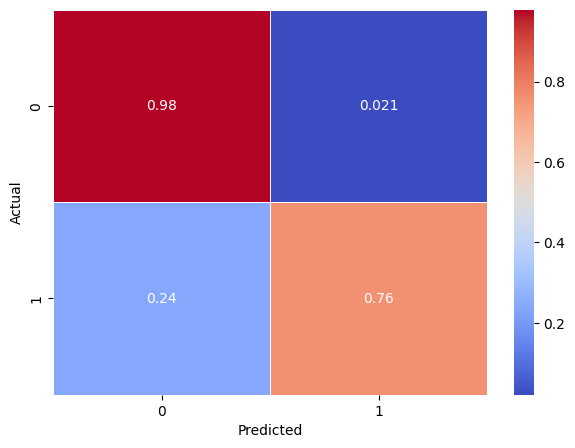

In [34]:

from lightgbm import LGBMClassifier, plot_importance
from sklearn.model_selection import StratifiedKFold

set_seed() #랜덤 고정

cv =StratifiedKFold(
    n_splits=5,# 각각의 모델이 몇번 학습할지 정의
    shuffle=True # 학습할 데이터셋을 랜덤하게 생성할지 여부
)

JWmodel = LGBMClassifier(verbose=-1)

from sklearn.metrics import roc_auc_score, roc_curve, auc

# cross Validation 교차 검증 학습
scores_tr=[]
scores_val=[]
scores_auc=[]
total_actual=[]
total_pred=[]
for i, (train_idx, valid_idx) in enumerate(cv.split(X_tr, y_tr)):
  # 교차 검증 학습데이터 생성
 train_feature= X_tr.iloc[train_idx]
 train_target= y_tr.iloc[train_idx]

  # 교차 검증 평가데이터 생성
 valid_feature= X_tr.iloc[valid_idx]
 valid_target= y_tr.iloc[valid_idx]

 #모델 학습
 JWmodel.fit(train_feature,train_target)
 #모델 평가
 score_tr = JWmodel.score(train_feature, train_target)
 score_val = JWmodel.score(valid_feature, valid_target)

 scores_tr.append(score_tr)
 scores_val.append(score_val)

 preds=JWmodel.predict(valid_feature)
 total_actual.extend(valid_target)
 total_pred.extend(preds)

 y_val_pred = JWmodel.predict_proba(valid_feature)[:,1]
 fpr, tpr, thresholds = roc_curve(valid_target,y_val_pred)
 auc_val = auc(fpr, tpr)

 scores_auc.append(auc_val)


print(f'model_train_acc:{np.array(scores_tr).mean()}'),print(f'model_val_acc:{np.array(scores_val).mean()}')

print(f'model_val_auc: {np.array(scores_auc).mean()}')


y_te_pred = JWmodel.predict_proba(X_te)[:,1]
fpr, tpr, thresholds = roc_curve(y_te,y_te_pred)
auc_te = auc(fpr, tpr)

print(f'model_te_auc: {auc_te}')

df_feature_importances = pd.DataFrame(JWmodel.feature_importances_, X_tr.columns).sort_values(by=[0], ascending=False).reset_index()
df_feature_importances

from sklearn.metrics import confusion_matrix

conf_mx = confusion_matrix(total_actual,total_pred, normalize="true")
conf_mx

plt.figure(figsize=(7,5))

sns.heatmap(conf_mx, annot=True, cmap="coolwarm", linewidth=0.5)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()





# cross validation

In [35]:
# Bayesian Search

import optuna
from sklearn.model_selection import cross_val_score


from optuna.samplers import TPESampler
optuna.logging.disable_default_handler()   


set_seed()
class Objective:
    def __init__(self,x_train,y_train,seed):

        self.x_train = x_train
        self.y_train = y_train
        self.seed = seed
        num_folds=5
        self.cv = StratifiedKFold(n_splits=num_folds,shuffle=True,random_state=self.seed)

    def __call__(self,trial):

        hp = {
            "max_depth" : trial.suggest_int("max_depth", 2, 5),
            "min_samples_split" : trial.suggest_int("min_samples_split", 2, 5),
            "criterion":trial.suggest_categorical("criterion",["gini","entropy"]),
            "max_leaf_nodes":trial.suggest_int("max_leaf_nodes",5,10),
            "n_estimators":trial.suggest_int("n_estimators",10,500,50),
            "learning_rate":trial.suggest_float("learning_rate",0.01,0.1), # Corrected from suggest_int to suggest_float
            "verbose":trial.suggest_categorical("verbose",[-1])
        }

        model=LGBMClassifier(random_state=self.seed,**hp)
        scores=cross_val_score(model,self.x_train,self.y_train, cv= self.cv, scoring="roc_auc")
        return np.mean(scores)

random_state=42
sampler = TPESampler(seed=random_state)

study=optuna.create_study(
    direction='maximize',
    sampler=sampler
)
objective=Objective(X_tr,y_tr,random_state)
study.optimize(objective,n_trials=50)

print(f"Best score:{study.best_value}")
print(f"Best hp:{study.best_params}")

JWmodel=LGBMClassifier(random_state=random_state,**study.best_params)
Best_JWmodel=JWmodel.fit(X_tr,y_tr)
preds=JWmodel.predict(X_te)
pred_final=Best_JWmodel.predict_proba(X_te)[:,1]
print(f"final model auc score:{roc_auc_score(y_te,pred_final)}")

C:\Users\Playdata\AppData\Local\Temp\ipykernel_8852\3819741941.py:28: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  "n_estimators":trial.suggest_int("n_estimators",10,500,50),
c:\Dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [10, 500] and step=50, but the range is not divisible by `step`. It will be replaced with [10, 460].
  optuna_warn(
C:\Users\Playdata\AppData\Local\Temp\ipykernel_8852\3819741941.py:28: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword argu

Best score:0.9621405338329744
Best hp:{'max_depth': 5, 'min_samples_split': 4, 'criterion': 'entropy', 'max_leaf_nodes': 9, 'n_estimators': 460, 'learning_rate': 0.08107934804645796, 'verbose': -1}
final model auc score:0.9756102451004961


# 모델 검증


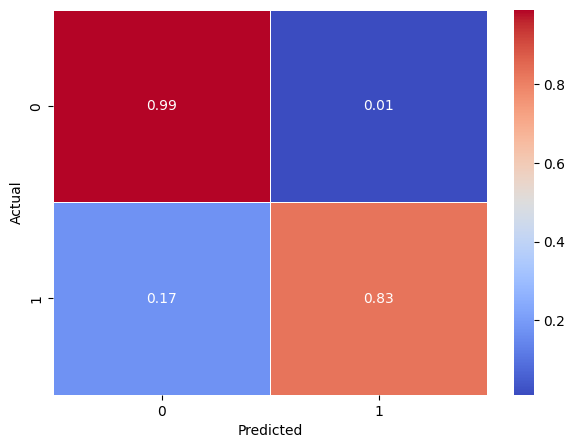

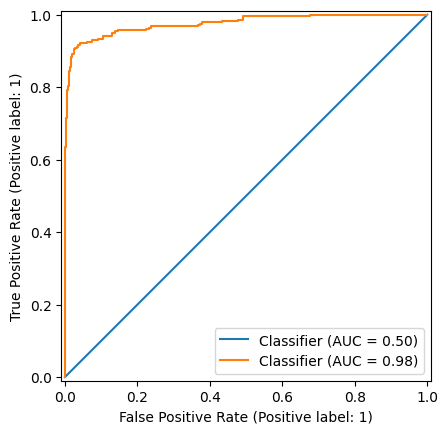

In [ ]:
set_seed()

from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_tr,y_tr)

pred_dummy = dummy.predict_proba(X_te)[:,1] 

conf_mx = confusion_matrix(y_te,preds, normalize="true")
conf_mx

plt.figure(figsize=(7,5))

sns.heatmap(conf_mx, annot=True, cmap="coolwarm", linewidth=0.5)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

from sklearn.metrics import RocCurveDisplay

fig,ax = plt.subplots()
RocCurveDisplay.from_predictions(y_te,pred_dummy,ax=ax)
RocCurveDisplay.from_predictions(y_te,pred_final,ax=ax)
plt.show()



# Best model 저장

In [37]:

import joblib

joblib.dump(Best_JWmodel, 'best_lgbm_JWmodel-01.pkl')

['best_lgbm_JWmodel-01.pkl']